##  Análisis Univariante 

### Variables analizadas

**Categóricas nominales:**
- `Primary Type` → tipo de crimen más común (H3, H4)
- `Location Description` → dónde ocurren los crímenes (H3)

**Numéricas discretas:**

- `Community Area` → barrios con más crímenes (H2)


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"



In [36]:
df = pd.read_parquet("../data/chicago_definitivo.parquet")

In [37]:
# Variables categóricas nominales
categoricas = [
    "Primary Type",
    "Location Description"
]

# Variables numéricas discretas
discretas = [
    "Community Area"
]



###  Frecuencias Absolutas
Top 10 categorías con mayor número de registros, ordenados de mayor a menor.

In [38]:
print("FRECUENCIAS ABSOLUTAS — Categóricas")
print("=" * 50)
for catego in categoricas:
    print(f"\nPara {catego}:")
    print(df[catego].value_counts().head(10))
    print()

FRECUENCIAS ABSOLUTAS — Categóricas

Para Primary Type:
Primary Type
THEFT                  35182
BATTERY                30091
NARCOTICS              16849
CRIMINAL DAMAGE        16408
OTHER OFFENSE          10728
ASSAULT                10530
DECEPTIVE PRACTICE      9482
BURGLARY                7923
MOTOR VEHICLE THEFT     5861
ROBBERY                 5649
Name: count, dtype: int64


Para Location Description:
Location Description
STREET                            37343
RESIDENCE                         26035
APARTMENT                         21133
SIDEWALK                          17448
OTHER                              6420
PARKING LOT/GARAGE(NON.RESID.)     4379
ALLEY                              3518
SCHOOL, PUBLIC, BUILDING           3315
SMALL RETAIL STORE                 3221
RESIDENTIAL YARD (FRONT/BACK)      3151
Name: count, dtype: int64



In [39]:
print("FRECUENCIAS ABSOLUTAS — Numéricas Discretas")
print("=" * 50)
for discreta in discretas:
    print(f"\nPara {discreta}:")
    print(df[discreta].value_counts().sort_index().head(10))
    print()

FRECUENCIAS ABSOLUTAS — Numéricas Discretas

Para Community Area:
Community Area
1     2218
2     2029
3     2229
4     1132
5      879
6     3204
7     2274
8     5228
9      159
10     766
Name: count, dtype: int64



### Frecuencias Relativas
Top 10 categorías con mayor porcentaje sobre el total, ordenados de mayor a menor.

In [40]:
print("FRECUENCIAS RELATIVAS (%) — Categóricas")
print("=" * 50)
for catego in categoricas:
    print(f"\nPara {catego}:")
    print((df[catego].value_counts(normalize=True) * 100).round(2).head(10).rename("porcentaje (%)"))
    print()

FRECUENCIAS RELATIVAS (%) — Categóricas

Para Primary Type:
Primary Type
THEFT                  21.66
BATTERY                18.52
NARCOTICS              10.37
CRIMINAL DAMAGE        10.10
OTHER OFFENSE           6.60
ASSAULT                 6.48
DECEPTIVE PRACTICE      5.84
BURGLARY                4.88
MOTOR VEHICLE THEFT     3.61
ROBBERY                 3.48
Name: porcentaje (%), dtype: float64


Para Location Description:
Location Description
STREET                            23.00
RESIDENCE                         16.04
APARTMENT                         13.02
SIDEWALK                          10.75
OTHER                              3.95
PARKING LOT/GARAGE(NON.RESID.)     2.70
ALLEY                              2.17
SCHOOL, PUBLIC, BUILDING           2.04
SMALL RETAIL STORE                 1.98
RESIDENTIAL YARD (FRONT/BACK)      1.94
Name: porcentaje (%), dtype: float64



In [41]:
print("FRECUENCIAS RELATIVAS (%) — Numéricas Discretas")
print("=" * 50)
for discreta in discretas:
    print(f"\nPara {discreta}:")
    print((df[discreta].value_counts(normalize=True).sort_index() * 100).round(2).head(10).rename("porcentaje(%)"))
    print()

FRECUENCIAS RELATIVAS (%) — Numéricas Discretas

Para Community Area:
Community Area
1     1.37
2     1.25
3     1.37
4     0.70
5     0.54
6     1.97
7     1.40
8     3.22
9     0.10
10    0.47
Name: porcentaje(%), dtype: float64



### Visualización — Gráficos de distribución
Representación visual de la distribución de cada variable.

#### PRIMARY TYPE

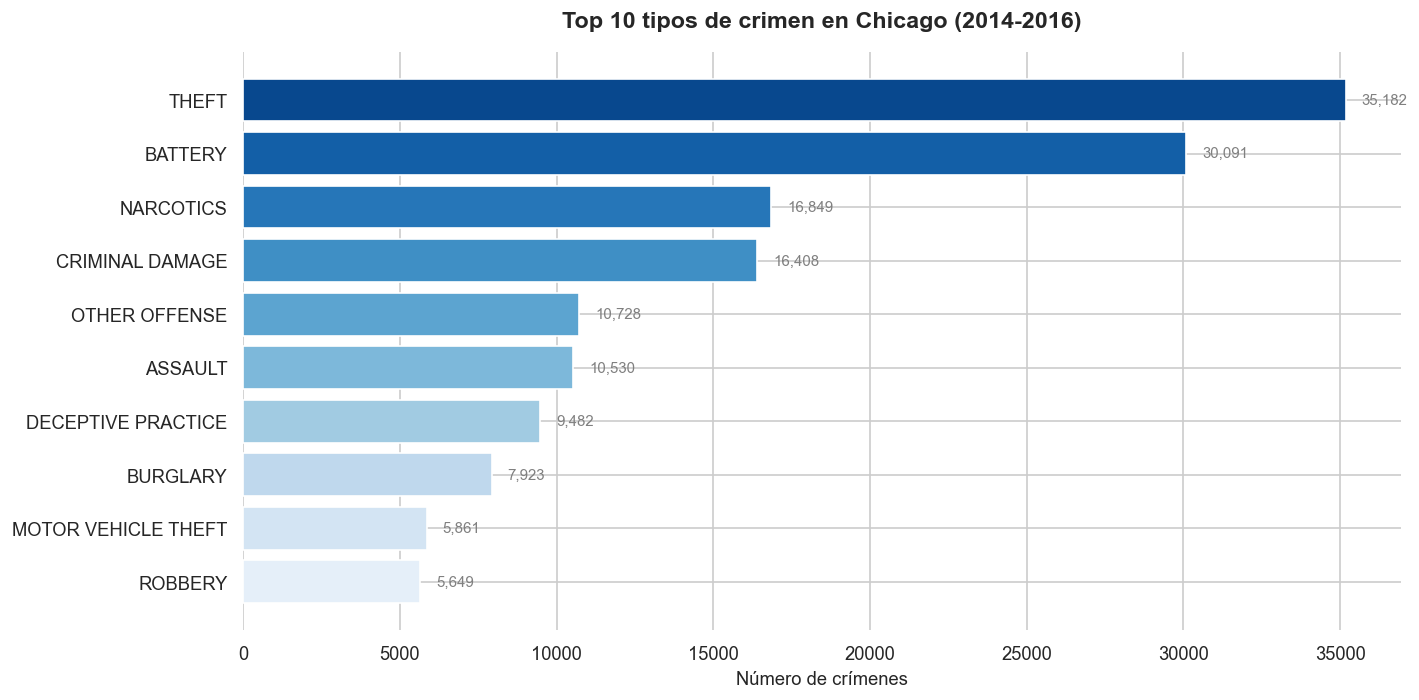

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

top_crimes = df["Primary Type"].value_counts().head(10)
colors = sns.color_palette("Blues_r", len(top_crimes))

bars = ax.barh(top_crimes.index, top_crimes.values, color=colors)

for bar, val in zip(bars, top_crimes.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, color="gray")

ax.set_title("Top 10 tipos de crimen en Chicago (2014-2016)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Número de crímenes", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


#### LOCATION DESCRIPTION

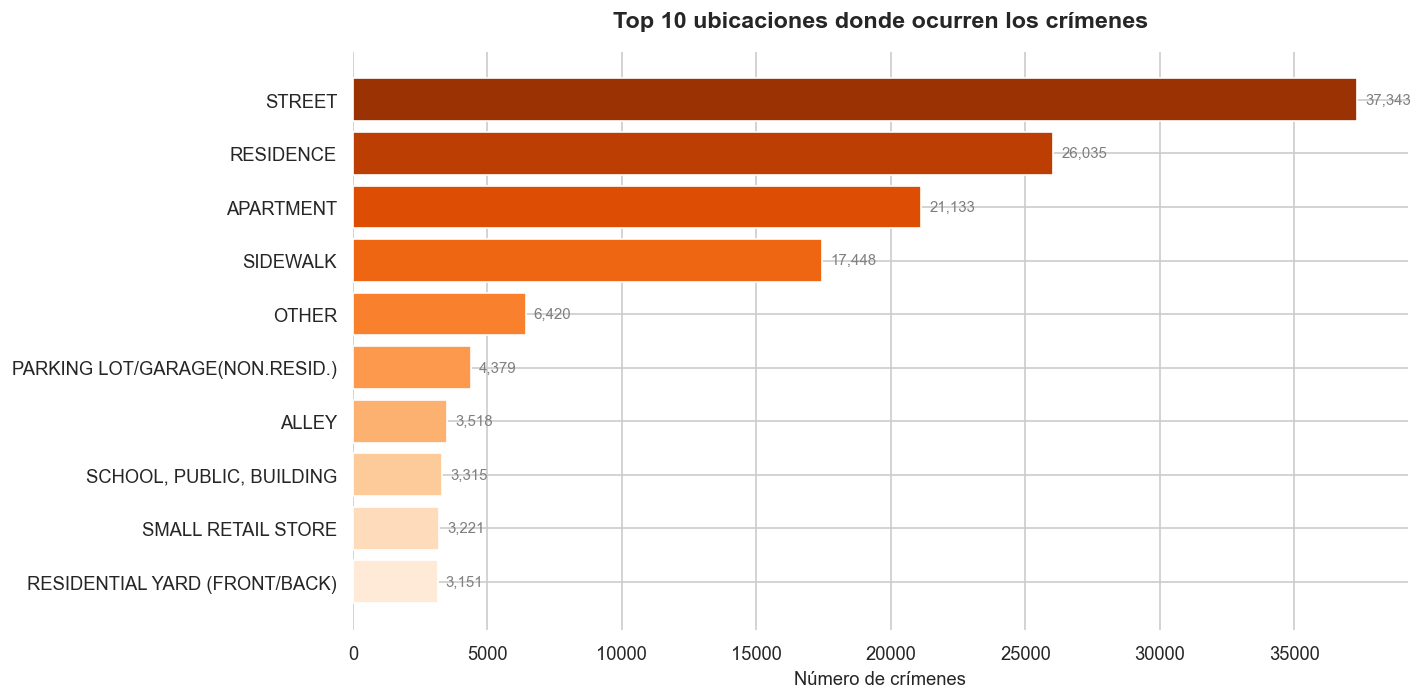

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

top_locations = df["Location Description"].value_counts().head(10)
colors = sns.color_palette("Oranges_r", len(top_locations))

bars = ax.barh(top_locations.index, top_locations.values, color=colors)

for bar, val in zip(bars, top_locations.values):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, color="gray")

ax.set_title("Top 10 ubicaciones donde ocurren los crímenes",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Número de crímenes", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#### COMMUNITY AREA

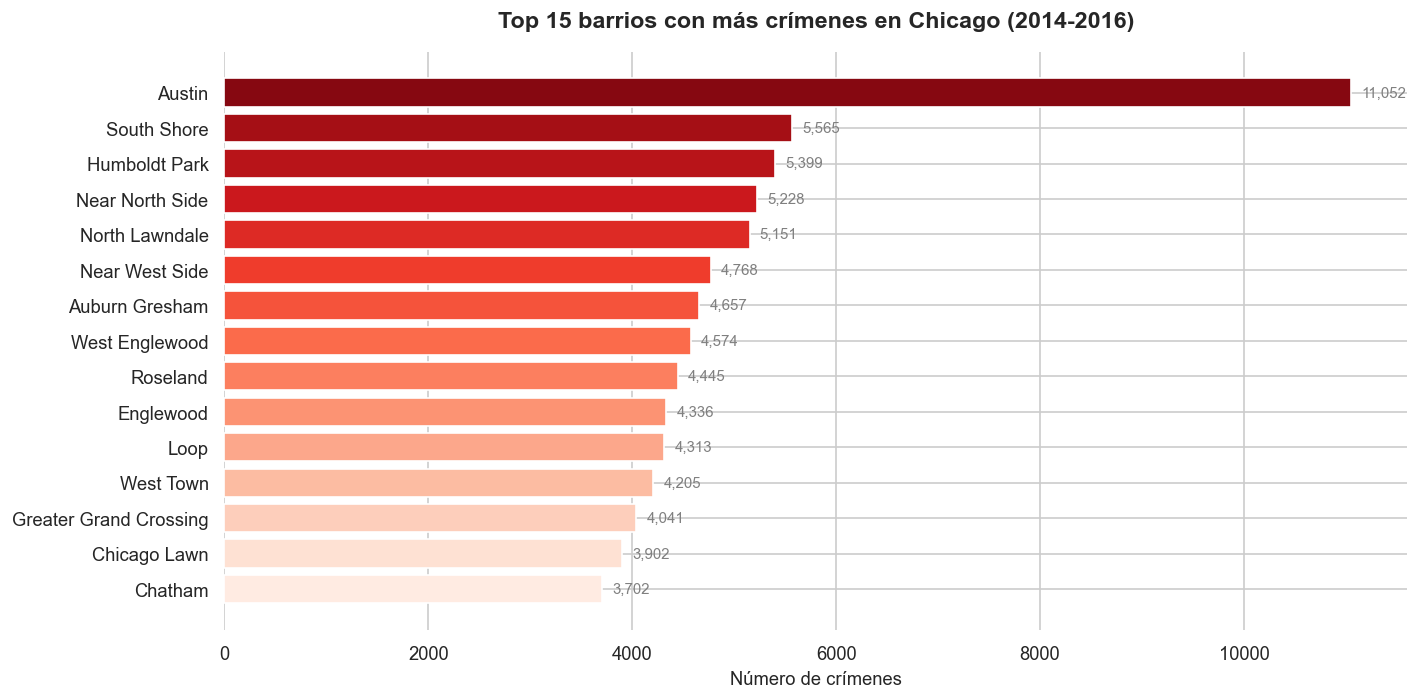

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))

top_barrios = df.groupby("neighborhood_name").size()\
                .sort_values(ascending=False).head(15)
colors = sns.color_palette("Reds_r", len(top_barrios))

bars = ax.barh(top_barrios.index, top_barrios.values, color=colors)

for bar, val in zip(bars, top_barrios.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, color="gray")

ax.set_title("Top 15 barrios con más crímenes en Chicago (2014-2016)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Número de crímenes", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

###  Conclusiones — Respuesta a las hipótesis

Resumen de los hallazgos del análisis univariante en relación 
a las hipótesis planteadas.

In [45]:
print("CONCLUSIONES DEL ANÁLISIS UNIVARIANTE")
print("=" * 55)

print("\n🔹 H1 — ¿Cuáles son los barrios con más crímenes?")
top1_barrio = df.groupby("neighborhood_name").size().idxmax()
top1_valor = df.groupby("neighborhood_name").size().max()
print(f"  El barrio de Chicago con más crímenes es {top1_barrio} con {top1_valor:,} casos")

print("\n🔹 H2 — ¿Qué crímenes son los más comunes?")
top1_crime = df["Primary Type"].value_counts().idxmax()
top1_crime_val = df["Primary Type"].value_counts().max()
pct = top1_crime_val / len(df) * 100
print(f"   El crimen más común en Chicago (2014-2016) es {top1_crime} con {top1_crime_val:,} casos ({pct:.1f}%)")
top1_loc = df["Location Description"].value_counts().idxmax()
print(f"   El lugar más frecuente donde ocurren es: {top1_loc}")

print("\n🔹 H3 — ¿Qué crímenes tienen mayor impunidad?")
print(f"   Pendiente de confirmar en el análisis bivariante")



CONCLUSIONES DEL ANÁLISIS UNIVARIANTE

🔹 H1 — ¿Cuáles son los barrios con más crímenes?
  El barrio de Chicago con más crímenes es Austin con 11,052 casos

🔹 H2 — ¿Qué crímenes son los más comunes?
   El crimen más común en Chicago (2014-2016) es THEFT con 35,182 casos (21.7%)
   El lugar más frecuente donde ocurren es: STREET

🔹 H3 — ¿Qué crímenes tienen mayor impunidad?
   Pendiente de confirmar en el análisis bivariante
